# Regression with PyTorch (oracle) — Income

**Role:** reference oracle used purely to check the from-scratch twin behaves correctly. Same data, same features, same architecture, same seed.

**EDA recap (slide_deck.html):** target `Income` (median $51,373, right-skewed to $666k, n=2,213 after dropping 24 missing-Income rows). Features = 3/3 consensus (8) + 2/3 (5) = 13 numeric columns, all-numeric → input dim = 13.

Pipeline: Load Data → Dataset Class → DataLoader → Model Class → Training Loop → Inference Loop. Weights saved to `./weights/regression_mlp.pt`.

**Target handling:** raw $ (~50k scale) would explode gradients under Adam lr=1e-3, so the model trains on z-scored `Income` (train-fit `StandardScaler`) and inverse-transforms for all reported metrics (raw $). The scratch twin does exactly the same.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("weights", exist_ok=True)
print("torch:", torch.__version__)

# ---- 1. LOAD DATA ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
print("raw:", df.shape)

df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
df = df.dropna(subset=["Income"]).copy()  # target can't be imputed: 2237 -> 2213
print("cleaned:", df.shape, "| Income median:", round(df["Income"].median()))

REG_FEATURES = [
    "NumCatalogPurchases", "MntMeatProducts", "MntWines", "NumWebVisitsMonth",
    "MntSweetProducts", "MntFruits", "NumWebPurchases", "MntGoldProds",  # 3/3
    "NumStorePurchases", "MntFishProducts", "Kidhome", "Age", "NumDealsPurchases",  # 2/3
]
X_full = df[REG_FEATURES].values
y_full = df["Income"].astype(float).values
print(f"features: {len(REG_FEATURES)} dims (all numeric)")

torch: 2.14.1
raw: (2240, 29)
cleaned: (2213, 28) | Income median: 51373
features: 13 dims (all numeric)


## 2–3. Dataset Class + DataLoader (80/20, features + target standardized with train-fit scalers)

In [2]:
class TabularDataset(Dataset):
    """Minimal torch Dataset: returns (x float32, y float32 shape (1,))."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32)).view(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED)
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_temp.reshape(-1, 1))
ytr_z = y_scaler.transform(y_temp.reshape(-1, 1)).ravel()
yte_z = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
print(f"train {Xtr.shape} test {Xte.shape} | y mean {y_full.mean():.0f} std {y_full.std():.0f}")
print(f"y scaler: mean {y_scaler.mean_[0]:.0f} scale {y_scaler.scale_[0]:.0f} (model trains on z, metrics in raw $)")

train_ds, test_ds = TabularDataset(Xtr, ytr_z), TabularDataset(Xte, yte_z)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                            generator=torch.Generator().manual_seed(SEED))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f"batches: {len(train_loader)} train / {len(test_loader)} test")

train (1770, 13) test (443, 13) | y mean 52237 std 25173
y scaler: mean 52026 scale 26009 (model trains on z, metrics in raw $)
batches: 28 train / 2 test


## 4. Model Class — shared spec: Linear(13→32) → ReLU → Linear(32→1), He init, no dropout

In [3]:
class RegMLP(nn.Module):
    def __init__(self, in_dim=13, h=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(h, 1)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity="relu")  # He init
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity="linear")
        nn.init.zeros_(self.fc2.bias)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

device = torch.device("cpu")  # forced cpu so NumPy twin matches exactly
model = RegMLP(in_dim=len(REG_FEATURES)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"params: {n_params} (expect 13*32+32 + 32*1+1 = 481)")
criterion = nn.MSELoss()  # loss in z-space
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)

RegMLP(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
params: 481 (expect 13*32+32 + 32*1+1 = 481)


## 5. Training Loop (50 epochs, Adam) — logs train/val MSE (z-space) + val RMSE (raw $), saves weights

epoch 01 | train_MSE_z 1.0161 | val_MSE_z 0.5988 | val_RMSE_$ 20126
epoch 10 | train_MSE_z 0.5236 | val_MSE_z 0.2444 | val_RMSE_$ 12859


epoch 20 | train_MSE_z 0.4909 | val_MSE_z 0.2087 | val_RMSE_$ 11881
epoch 30 | train_MSE_z 0.4774 | val_MSE_z 0.1971 | val_RMSE_$ 11548


epoch 40 | train_MSE_z 0.4686 | val_MSE_z 0.1888 | val_RMSE_$ 11302
epoch 50 | train_MSE_z 0.4641 | val_MSE_z 0.1852 | val_RMSE_$ 11194
saved: weights/regression_mlp.pt + scaler.npz + pytorch_history.csv


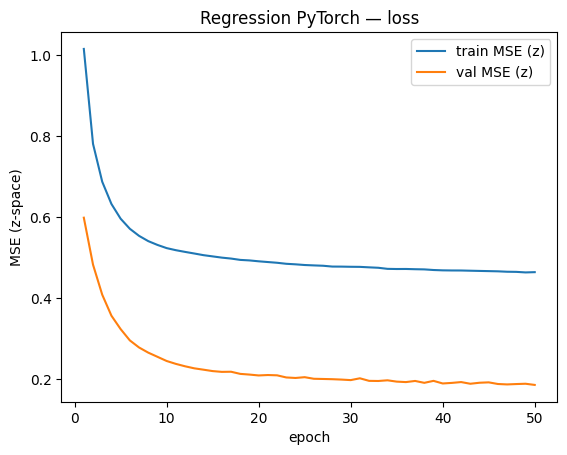

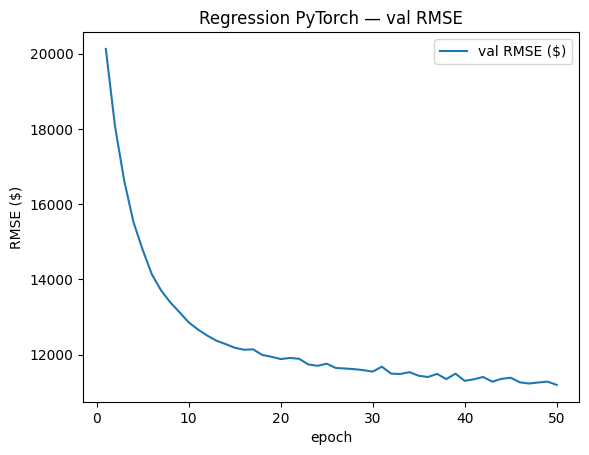

In [4]:
EPOCHS = 50
history = {"epoch": [], "train_loss_z": [], "val_loss_z": [], "val_rmse": []}
mse = nn.MSELoss()

def evaluate(m):
    m.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
        pred_z = m(Xt).cpu().numpy().ravel()
        pred = y_scaler.inverse_transform(pred_z.reshape(-1, 1)).ravel()
        loss_z = float(np.mean((pred_z - yte_z) ** 2))
        rmse = float(np.sqrt(np.mean((pred - y_test) ** 2)))
        return loss_z, rmse

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * len(xb); n += len(xb)
    vl_z, vr = evaluate(model)
    history["epoch"].append(epoch)
    history["train_loss_z"].append(tot / n)
    history["val_loss_z"].append(vl_z)
    history["val_rmse"].append(vr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | train_MSE_z {tot/n:.4f} | val_MSE_z {vl_z:.4f} | val_RMSE_$ {vr:.0f}")

torch.save(model.state_dict(), "weights/regression_mlp.pt")
np.savez("weights/regression_scaler.npz", mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(REG_FEATURES), y_mean=y_scaler.mean_, y_scale=y_scaler.scale_)
pd.DataFrame(history).to_csv("weights/regression_pytorch_history.csv", index=False)
print("saved: weights/regression_mlp.pt + scaler.npz + pytorch_history.csv")

plt.figure(); plt.plot(history["epoch"], history["train_loss_z"], label="train MSE (z)")
plt.plot(history["epoch"], history["val_loss_z"], label="val MSE (z)")
plt.xlabel("epoch"); plt.ylabel("MSE (z-space)"); plt.legend(); plt.title("Regression PyTorch — loss"); plt.show()
plt.figure(); plt.plot(history["epoch"], history["val_rmse"], label="val RMSE ($)")
plt.xlabel("epoch"); plt.ylabel("RMSE ($)"); plt.legend(); plt.title("Regression PyTorch — val RMSE"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights/regression_mlp.pt`, metrics in raw $

In [5]:
fresh = RegMLP(in_dim=len(REG_FEATURES)).to(device)
fresh.load_state_dict(torch.load("weights/regression_mlp.pt", map_location=device))
fresh.eval()
with torch.no_grad():
    Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
    pred = y_scaler.inverse_transform(fresh(Xt).cpu().numpy()).ravel()
test_mse = float(mean_squared_error(y_test, pred))
metrics = {
    "test_loss_MSE_raw": round(test_mse, 1),
    "rmse": round(float(np.sqrt(test_mse)), 1),
    "mae": round(float(mean_absolute_error(y_test, pred)), 1),
    "r2": round(float(r2_score(y_test, pred)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights/regression_pytorch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nsample predictions (pred $ vs true $):")
for i in range(5):
    print(f"  pred={pred[i]:.0f} true={y_test[i]:.0f}")

{
  "test_loss_MSE_raw": 125307774.9,
  "rmse": 11194.1,
  "mae": 7170.3,
  "r2": 0.7287,
  "n_test": 443,
  "seed": 42
}

sample predictions (pred $ vs true $):
  pred=69844 true=62450
  pred=39474 true=37235
  pred=73479 true=65492
  pred=40365 true=42618
  pred=35060 true=26997
